Loaded 86 rows
Date range: 2026-02-23 00:00:00 to 2026-05-23 00:00:00


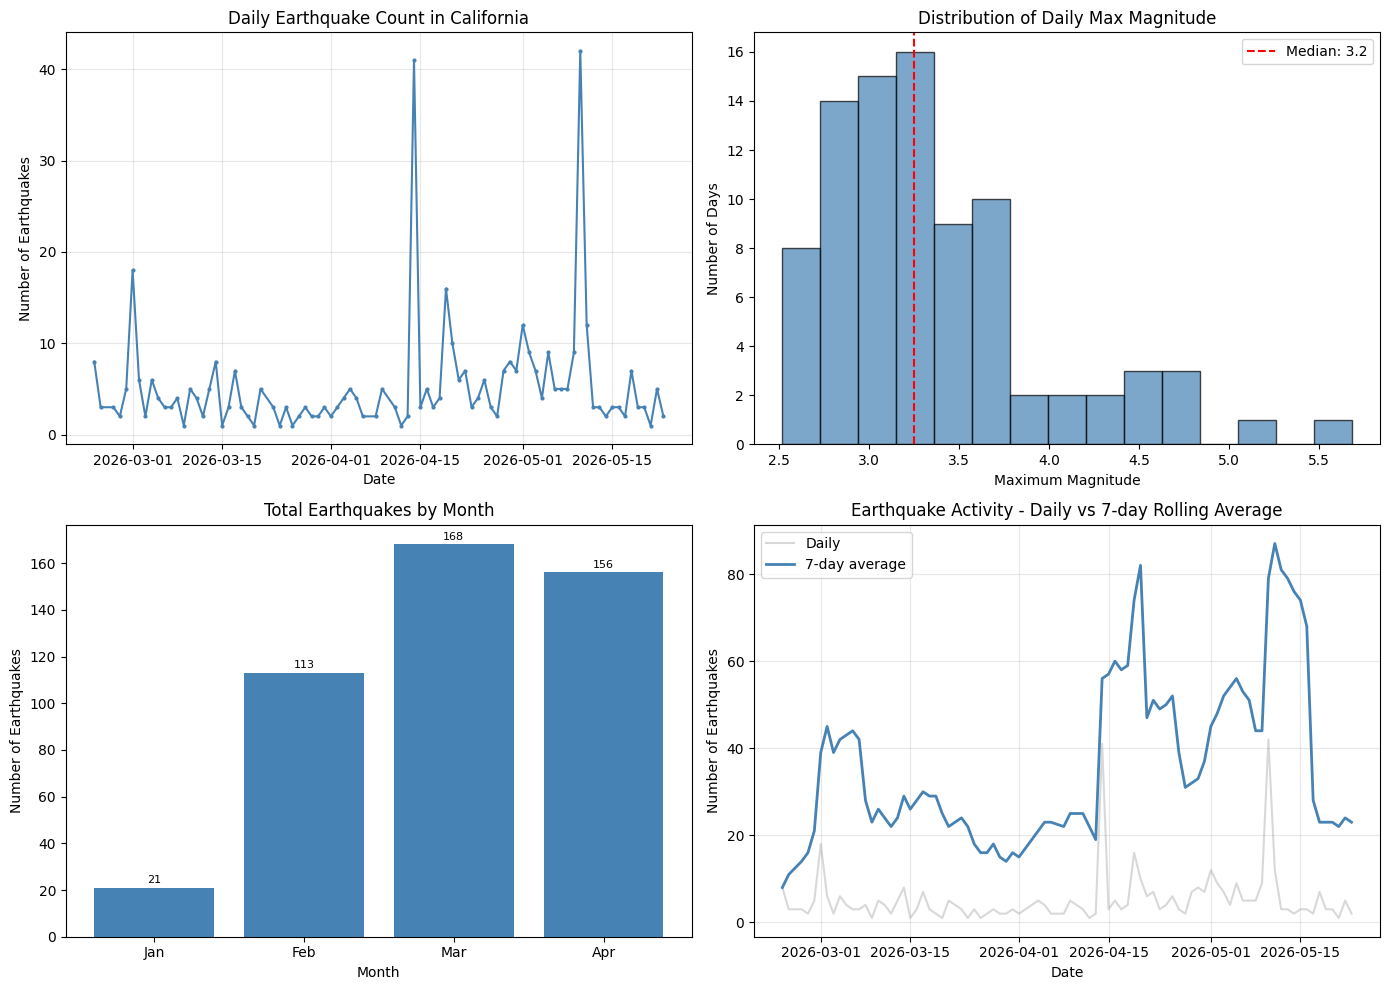

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

files = list(Path("../data/mart").glob("*.csv"))
if not files:
    raise FileNotFoundError("No CSV files in data/mart/")

mart_path = files[0]
df = pd.read_csv(mart_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(df['date'], df['earthquake_count'], color='steelblue', linewidth=1.5, marker='o', markersize=2)
plt.title('Daily Earthquake Count in California', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(df['max_magnitude'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Max Magnitude', fontsize=12)
plt.xlabel('Maximum Magnitude')
plt.ylabel('Number of Days')
plt.axvline(df['max_magnitude'].median(), color='red', linestyle='--', label=f'Median: {df["max_magnitude"].median():.1f}')
plt.legend()

plt.subplot(2, 2, 3)
monthly = df.groupby(df['date'].dt.month).agg(total_earthquakes=('earthquake_count', 'sum')).reset_index()
monthly['month_name'] = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(monthly)]
bars = plt.bar(monthly['month_name'], monthly['total_earthquakes'], color='steelblue')
plt.title('Total Earthquakes by Month', fontsize=12)
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
for bar, val in zip(bars, monthly['total_earthquakes']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(int(val)), ha='center', fontsize=8)

plt.subplot(2, 2, 4)
plt.plot(df['date'], df['earthquake_count'], alpha=0.3, color='gray', label='Daily')
plt.plot(df['date'], df['earthquake_count_7d'], color='steelblue', linewidth=2, label='7-day average')
plt.title('Earthquake Activity - Daily vs 7-day Rolling Average', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/figures/week7_all_plots.png", dpi=150)
plt.show()

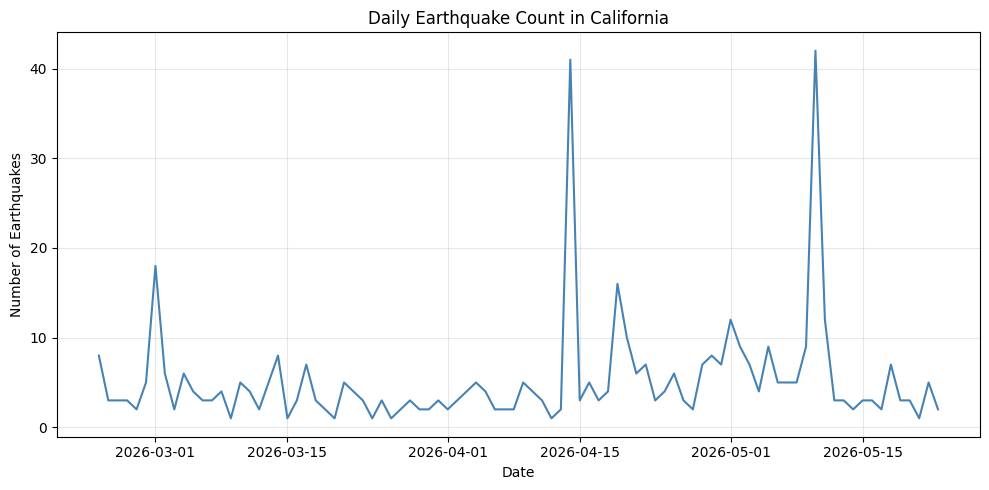

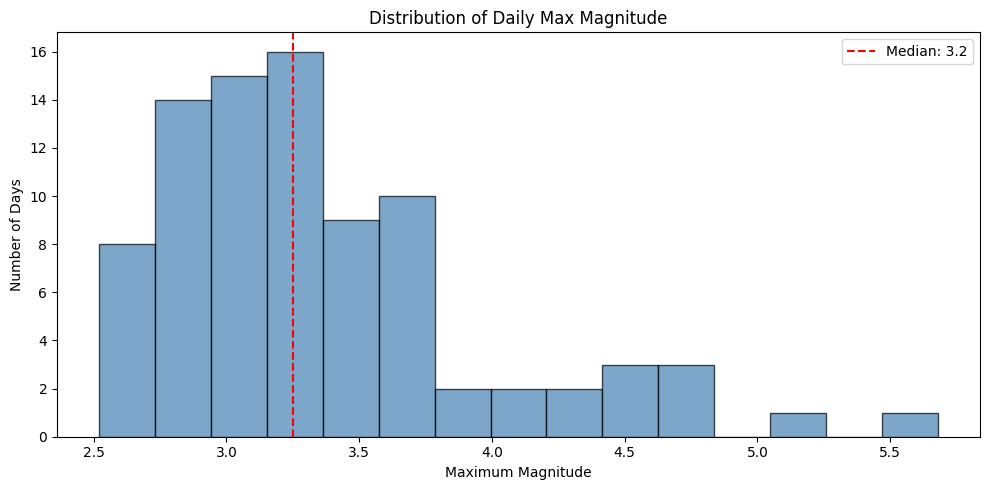

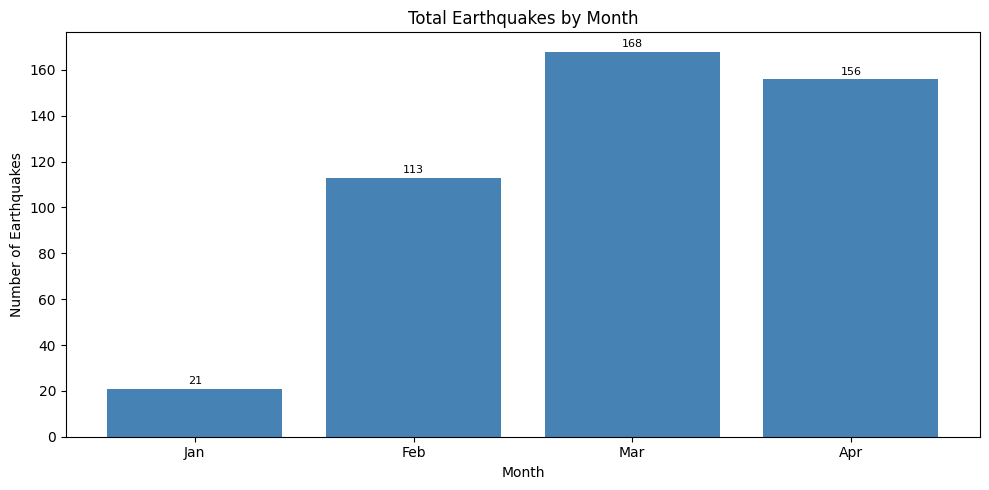

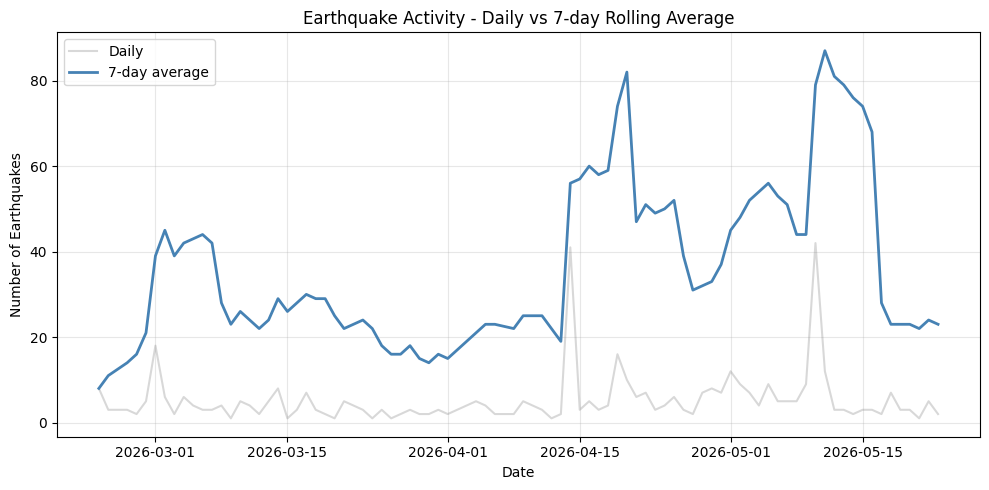

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

files = list(Path("../data/mart").glob("*.csv"))
mart_path = files[0]
df = pd.read_csv(mart_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['earthquake_count'], color='steelblue', linewidth=1.5)
plt.title('Daily Earthquake Count in California', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/figures/week7_timeseries.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df['max_magnitude'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Max Magnitude', fontsize=12)
plt.xlabel('Maximum Magnitude')
plt.ylabel('Number of Days')
plt.axvline(df['max_magnitude'].median(), color='red', linestyle='--', label=f'Median: {df["max_magnitude"].median():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig("../docs/figures/week7_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
monthly = df.groupby(df['date'].dt.month).agg(total_earthquakes=('earthquake_count', 'sum')).reset_index()
monthly['month_name'] = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(monthly)]
bars = plt.bar(monthly['month_name'], monthly['total_earthquakes'], color='steelblue')
plt.title('Total Earthquakes by Month', fontsize=12)
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
for bar, val in zip(bars, monthly['total_earthquakes']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(int(val)), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("../docs/figures/week7_ranking.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['earthquake_count'], alpha=0.3, color='gray', label='Daily')
plt.plot(df['date'], df['earthquake_count_7d'], color='steelblue', linewidth=2, label='7-day average')
plt.title('Earthquake Activity - Daily vs 7-day Rolling Average', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/figures/week7_rolling.png", dpi=150)
plt.show()

1. Самая частая амплитуда землетрясений между 3 и 3.5
2. Чаще всего землетрясения в марте, а затем апрель и февраль
3. 2026-04-15 и 2026-05-15 активность больше всего землетрясений